In [9]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [6]:
class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float

In [7]:
def calculate_bmi(state: BMIState) -> BMIState:
    bmi = state['weight'] / (state['height'] ** 2)
    state['bmi'] = round(bmi,2)
    return state

In [10]:
graph = StateGraph(BMIState)
# add nodes to the graph
graph.add_node("bmi_calculate",calculate_bmi)

# add edges
graph.add_edge(START,"bmi_calculate")
graph.add_edge("bmi_calculate",END)

# compile the graph
workflow = graph.compile()

In [11]:
# execute the graph
initial_state = {
    "weight": 70,
    "height": 1.75
}

final_state = workflow.invoke(initial_state)
print(final_state)

{'weight': 70, 'height': 1.75, 'bmi': 22.86}


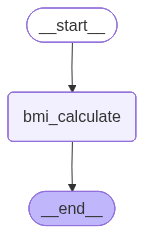

In [12]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())